# Play Mario (Phase 1) — everything visible inside Jupyter

A random agent plays Super Mario Bros. We watch it **inside this page**:
1. run the agent and collect the frames
2. show a few frames inline
3. replay the whole run as a video, embedded in the notebook

The container is headless (no game window), so we look at the result here
instead of watching a live window.

In [9]:
import matplotlib.pyplot as plt
import gym_super_mario_bros
from gym_super_mario_bros.actions import SIMPLE_MOVEMENT
from nes_py.wrappers import JoypadSpace

In [10]:
# gym version differences: reset() may return obs or (obs, info);
# step() may return 4 or 5 values. These helpers make us robust to both.
def unpack_reset(ret):
    return ret[0] if isinstance(ret, tuple) else ret

def unpack_step(ret):
    if len(ret) == 5:
        obs, reward, terminated, truncated, info = ret
        return obs, reward, terminated or truncated, info
    return ret  # obs, reward, done, info

In [11]:
STEPS = 600

env = JoypadSpace(gym_super_mario_bros.make("SuperMarioBros-v0"), SIMPLE_MOVEMENT)
print("action space:", env.action_space)

obs = unpack_reset(env.reset())
# nes-py reuses (and frees on close) its screen buffer, so copy every frame.
frames = [obs.copy()]
max_x = 0
for _ in range(STEPS):
    action = env.action_space.sample()  # random button press
    obs, reward, done, info = unpack_step(env.step(action))
    frames.append(obs.copy())
    max_x = max(max_x, info.get("x_pos", 0))
    if done:
        obs = unpack_reset(env.reset())
        frames.append(obs.copy())
env.close()

print(f"collected {len(frames)} frames, furthest x_pos reached: {max_x}")

action space: Discrete(7)
collected 601 frames, furthest x_pos reached: 435


## A few frames along the run

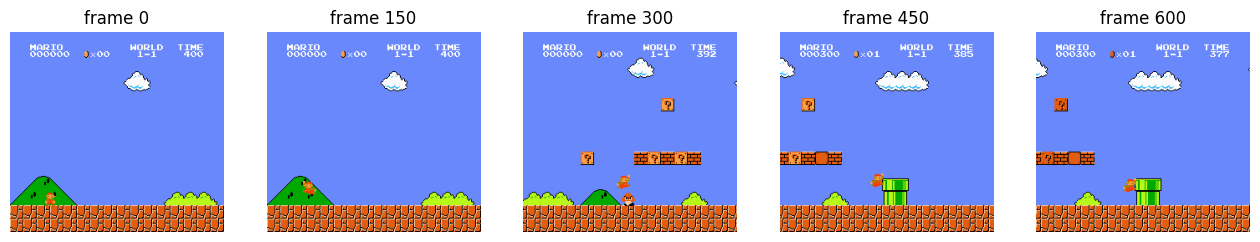

In [12]:
idx = [0, len(frames) // 4, len(frames) // 2, 3 * len(frames) // 4, len(frames) - 1]
fig, axes = plt.subplots(1, len(idx), figsize=(16, 4))
for ax, i in zip(axes, idx):
    ax.imshow(frames[i])
    ax.set_title(f"frame {i}")
    ax.axis("off")
plt.show()

## Replay the whole run as a video (embedded in the page)

In [13]:
import imageio
from IPython.display import Video

OUT = "../data/random_agent.mp4"
imageio.mimsave(OUT, frames, fps=30)
Video(OUT, embed=True, width=384)